# Experiment Plan: Fill Table

In [2]:
import pandas as pd
df = pd.read_csv('results/experiment_results.csv')
df

,Method,random_seed,d,epsilonX,epsilonEI,i,EI,y,y*,R,t (s),m (MB)
0,exactBO,0,2,0.00001,0.1,1,0.049408,1.391567,-1.910187,0.000000,0.188449,NaN
1,exactBO,0,2,0.00001,0.1,2,0.052902,-0.727726,-1.910187,2.119293,0.185696,NaN
2,exactBO,0,2,0.00001,0.1,3,0.088452,-1.271223,-1.910187,3.206287,0.219197,NaN
3,exactBO,0,2,0.00001,0.1,4,0.286745,-1.355857,-1.910187,3.460188,1.230342,NaN
4,exactBO,0,2,0.00001,0.1,5,0.118775,-0.978122,-1.910187,3.837923,2.351466,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
395,gradBO,9,2,0.00001,NaN,6,0.067501,0.012648,-1.910187,7.563271,0.123487,NaN
396,gradBO,9,2,0.00001,NaN,7,0.029373,-0.850356,-1.910187,7.634731,0.187534,NaN
397,gradBO,9,2,0.00001,NaN,8,0.046577,0.953981,-1.910187,9.510528,0.123190,NaN
398,gradBO,9,2,0.00001,NaN,9,0.031057,1.999941,-1.910187,12.432285,0.128258,NaN


# Regret
At iteration $i$, let $y_1, \dots, y_i \in \Omega$:
$$R(i)=\sum_{j=1}^i \left| y_j - y* \right| - i\min_{y\in \Omega} \left\{ \left| y - y* \right| \right\} $$

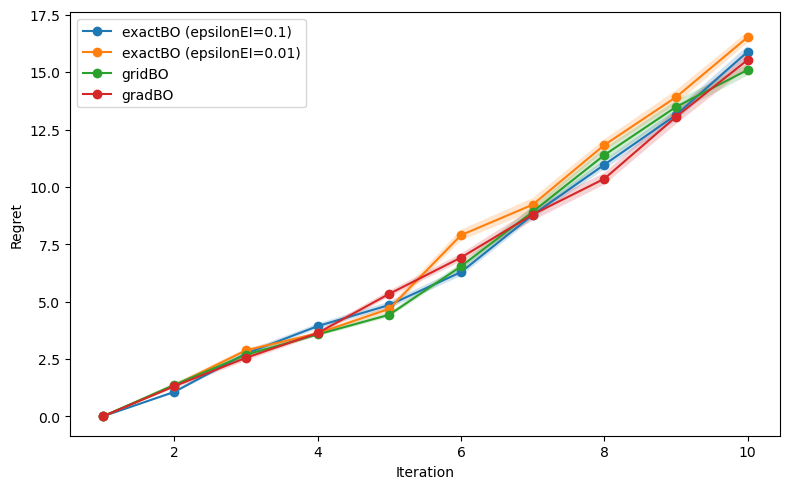

In [9]:
import matplotlib.pyplot as plt

df_regret = df[df['d'] == 2].copy()
df_regret['Framework'] = df_regret.apply(
    lambda row: f"exactBO (epsilonEI={row['epsilonEI']})" if row['Method'] == 'exactBO' else row['Method'],
    axis=1,
)

regret_summary = (
    df_regret.groupby(['Framework', 'i'], as_index=False)['R']
    .agg(mean='mean', std='std')
    .fillna({'std': 0.0})
)

framework_order = [
    'exactBO (epsilonEI=0.1)',
    'exactBO (epsilonEI=0.01)',
    'gridBO',
    'gradBO',
]

plt.figure(figsize=(8, 5))
for framework in framework_order:
    framework_summary = regret_summary[regret_summary['Framework'] == framework].sort_values('i')
    if framework_summary.empty:
        continue

    plt.plot(framework_summary['i'], framework_summary['mean'], marker='o', label=framework)
    plt.fill_between(
        framework_summary['i'],
        framework_summary['mean'] - 0.1*framework_summary['std'],
        framework_summary['mean'] + 0.1*framework_summary['std'],
        alpha=0.2,
    )

plt.xlabel('Iteration')
plt.ylabel('Regret')
plt.legend()
plt.tight_layout()
plt.show()

# Time

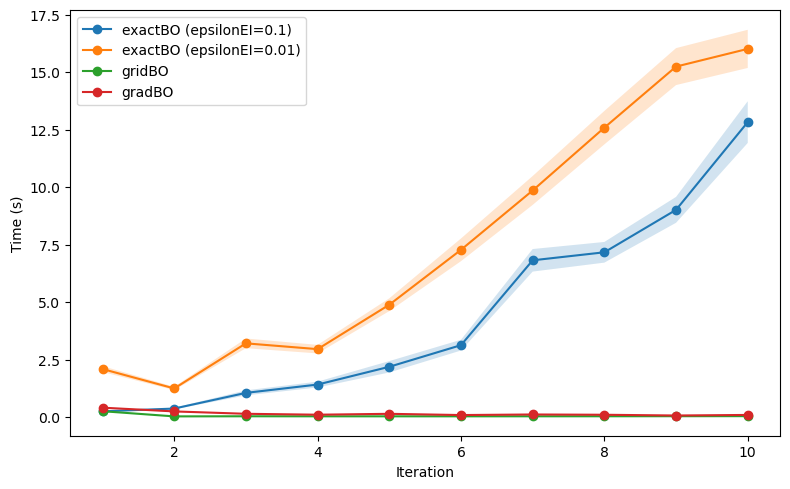

In [11]:
import matplotlib.pyplot as plt

df_regret = df[df['d'] == 2].copy()
df_regret['Framework'] = df_regret.apply(
    lambda row: f"exactBO (epsilonEI={row['epsilonEI']})" if row['Method'] == 'exactBO' else row['Method'],
    axis=1,
)

regret_summary = (
    df_regret.groupby(['Framework', 'i'], as_index=False)['t (s)']
    .agg(mean='mean', std='std')
    .fillna({'std': 0.0})
)

framework_order = [
    'exactBO (epsilonEI=0.1)',
    'exactBO (epsilonEI=0.01)',
    'gridBO',
    'gradBO',
]

plt.figure(figsize=(8, 5))
for framework in framework_order:
    framework_summary = regret_summary[regret_summary['Framework'] == framework].sort_values('i')
    if framework_summary.empty:
        continue

    plt.plot(framework_summary['i'], framework_summary['mean'], marker='o', label=framework)
    plt.fill_between(
        framework_summary['i'],
        framework_summary['mean'] - 0.1*framework_summary['std'],
        framework_summary['mean'] + 0.1*framework_summary['std'],
        alpha=0.2,
    )

plt.xlabel('Iteration')
plt.ylabel('Time (s)')
plt.legend()
plt.tight_layout()
plt.show()

# Convergence

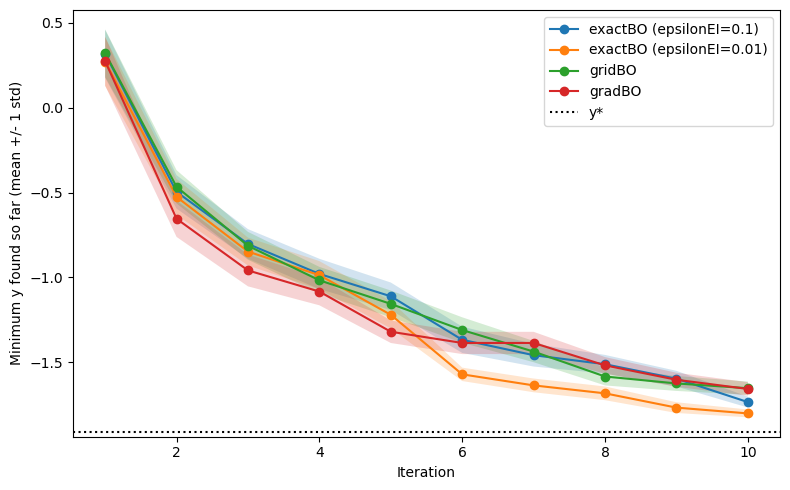

In [10]:
import matplotlib.pyplot as plt

df_best_y = df[df['d'] == 2].copy()
df_best_y['Framework'] = df_best_y.apply(
    lambda row: f"exactBO (epsilonEI={row['epsilonEI']})" if row['Method'] == 'exactBO' else row['Method'],
    axis=1,
)
df_best_y = df_best_y.sort_values(['Framework', 'random_seed', 'i'])
df_best_y['best_y_so_far'] = df_best_y.groupby(['Framework', 'random_seed'])['y'].cummin()

best_y_summary = (
    df_best_y.groupby(['Framework', 'i'], as_index=False)['best_y_so_far']
    .agg(mean='mean', std='std')
    .fillna({'std': 0.0})
)

framework_order = [
    'exactBO (epsilonEI=0.1)',
    'exactBO (epsilonEI=0.01)',
    'gridBO',
    'gradBO',
]
y_star = df_best_y['y*'].dropna().iloc[0]

plt.figure(figsize=(8, 5))
for framework in framework_order:
    framework_summary = best_y_summary[best_y_summary['Framework'] == framework].sort_values('i')
    if framework_summary.empty:
        continue

    plt.plot(framework_summary['i'], framework_summary['mean'], marker='o', label=framework)
    plt.fill_between(
        framework_summary['i'],
        framework_summary['mean'] - 0.1*framework_summary['std'],
        framework_summary['mean'] + 0.1*framework_summary['std'],
        alpha=0.2,
    )

plt.axhline(y_star, color='black', linestyle=':', linewidth=1.5, label='y*')
plt.xlabel('Iteration')
plt.ylabel('Minimum y found so far (mean +/- 1 std)')
plt.legend()
plt.tight_layout()
plt.show()
